In [ ]:
# SYSTEM & FILE (Untuk akses Drive, folder, dan simpan hasil)
from google.colab import drive
import os
from glob import glob
import pickle
import gc # Penting buat bersihin RAM tiap ganti Fold

# DATA & VISUALISASI (Olah gambar dan bikin grafik)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TENSORFLOW/KERAS
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# MACHINE LEARNING UTILS (Bagi data dan evaluasi)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Configuration & Hyperparameters

# !cp -r "/content/drive/MyDrive/22-023_Ali Ridho/Dataset" "/content/"
DATASET_PATH = "/content/Dataset"  # Path lokal di colab

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 4
K_FOLDS = 5
TEST_SPLIT = 0.2  # 80% train, 20% test (unseen)

# Random seed untuk reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
# Load dan Prepare Dataset

def load_dataset(dataset_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))

    print(f"Class names: {class_names}")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue

        image_files = glob(os.path.join(class_path, '*.*'))
        print(f"Class {class_name}: {len(image_files)} images")

        for img_path in image_files:
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(idx)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    images = np.array(images, dtype='float32')
    labels = np.array(labels)

    print(f"\nTotal images: {len(images)}")
    print(f"Image shape: {images.shape}")
    print(f"Image value range: [{images.min()}, {images.max()}]")
    print(f"Labels shape: {labels.shape}")

    return images, labels, class_names

# Load dataset dari local storage
print(f"Loading dataset from: {DATASET_PATH}")
X, y, class_names = load_dataset(DATASET_PATH)

# Rescale images ke [0, 1]
print("\nRescaling images from [0, 255] to [0, 1]...")
X = X / 255.0
print(f"After rescaling: [{X.min()}, {X.max()}]")

# Split train-test (test adalah unseen data)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

print(f"\nTrain set: {len(X_train_full)} images")
print(f"Test set (unseen): {len(X_test)} images")


Loading dataset from: /content/Dataset
Class names: ['blast', 'brown_spot', 'hispa', 'normal']
Class blast: 1738 images
Class brown_spot: 965 images
Class hispa: 1594 images
Class normal: 1764 images

Total images: 6061
Image shape: (6061, 224, 224, 3)
Image value range: [0.0, 255.0]
Labels shape: (6061,)

Rescaling images from [0, 255] to [0, 1]...
After rescaling: [0.0, 1.0]

Train set: 4848 images
Test set (unseen): 1213 images


In [ ]:
# TRIPLET ATTENTION MODULES
class ZPool(layers.Layer):
    """Z-Pooling: Concatenate max and mean pooling along channel dimension"""
    def call(self, x):
        max_pool = tf.reduce_max(x, axis=-1, keepdims=True)
        mean_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
        return tf.concat([max_pool, mean_pool], axis=-1)


class AttentionGate(layers.Layer):
    """Attention Gate dengan Z-Pool + Conv"""
    def __init__(self, kernel_size=7, **kwargs):
        super(AttentionGate, self).__init__(**kwargs)
        self.compress = ZPool()
        # use_bias=False karena BatchNorm sudah ada biasnya
        self.conv = layers.Conv2D(1, kernel_size, padding='same',
                                  use_bias=False, activation='sigmoid')

    def call(self, x):
        x_compress = self.compress(x)
        scale = self.conv(x_compress)
        return x * scale


class TripletAttention(layers.Layer):
    """
    Triplet Attention Module
    Menangkap dependencies cross-dimension: H-W, C-W, H-C
    """
    def __init__(self, **kwargs):
        super(TripletAttention, self).__init__(**kwargs)
        self.cw_gate = AttentionGate()
        self.hc_gate = AttentionGate()
        self.hw_gate = AttentionGate()

    def call(self, x):
        # Branch 1: Spatial (Height-Width)
        x_hw = self.hw_gate(x)

        # Branch 2: Channel-Width (C-W)
        # Transpose: (B, H, W, C) -> (B, C, W, H)
        x_perm1 = tf.transpose(x, perm=[0, 3, 2, 1])
        x_cw = self.cw_gate(x_perm1)
        # Transpose kembali: (B, C, W, H) -> (B, H, W, C)
        x_cw = tf.transpose(x_cw, perm=[0, 3, 2, 1])

        # Branch 3: Height-Channel (H-C)
        # Transpose: (B, H, W, C) -> (B, H, C, W)
        x_perm2 = tf.transpose(x, perm=[0, 1, 3, 2])
        x_hc = self.hc_gate(x_perm2)
        # Transpose kembali: (B, H, C, W) -> (B, H, W, C)
        x_hc = tf.transpose(x_hc, perm=[0, 1, 3, 2])

        # Rata-rata dari ketiga cabang
        return (x_hw + x_cw + x_hc) / 3


In [ ]:
# BOTTLENECK BLOCK

def bottleneck_block(x, filters, stride=1, downsample=False, name=None):
    """
    Bottleneck Block untuk ResNet-50
    Struktur: 1x1 -> 3x3 -> 1x1 (expansion 4x)
    """
    shortcut = x
    in_channels = x.shape[-1]

    # Conv 1x1
    x = layers.Conv2D(filters, (1, 1), strides=stride, padding='same',
                     use_bias=False, name=f"{name}_1_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_1_bn")(x)
    x = layers.Activation('relu', name=f"{name}_1_relu")(x)

    # Conv 3x3
    x = layers.Conv2D(filters, (3, 3), strides=1, padding='same',
                     use_bias=False, name=f"{name}_2_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_2_bn")(x)
    x = layers.Activation('relu', name=f"{name}_2_relu")(x)

    # Conv 1x1 (Expansion 4x)
    x = layers.Conv2D(filters * 4, (1, 1), strides=1, padding='same',
                     use_bias=False, name=f"{name}_3_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_3_bn")(x)

    # Shortcut connection
    if downsample or in_channels != filters * 4:
        shortcut = layers.Conv2D(filters * 4, (1, 1), strides=stride,
                                padding='same', use_bias=False,
                                name=f"{name}_0_conv")(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_0_bn")(shortcut)

    # Add shortcut + activation
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    x = layers.Activation('relu', name=f"{name}_out")(x)

    return x

In [ ]:

# ResNet-50 + Triplet Attention Architecture
def build_resnet50_triplet_attention(num_classes=4, input_shape=(224, 224, 3),
                                     use_attention=True):

    inputs = layers.Input(shape=input_shape)

    # Initial layers
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same',
                     use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation('relu', name="stem_relu")(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same', name="stem_pool")(x)

    # STAGES (Stage 2, 3, 4, 5)

    # Konfigurasi ResNet-50: [3, 4, 6, 3] blocks per stage
    block_counts = [3, 4, 6, 3]
    filter_sizes = [64, 128, 256, 512]

    for stage, (filters, blocks) in enumerate(zip(filter_sizes, block_counts)):
        print(f"Building Stage {stage + 2} with {blocks} blocks, filters={filters}")

        for block in range(blocks):
            downsample = (block == 0)
            stride = 2 if (block == 0 and stage != 0) else 1
            block_name = f"stage{stage + 2}_block{block + 1}"

            x = bottleneck_block(x, filters, stride=stride,
                               downsample=downsample, name=block_name)

        # TRIPLET ATTENTION DI AKHIR SETIAP STAGE
        if use_attention:
            x = TripletAttention(name=f"triplet_attention_stage{stage + 2}")(x)
            print(f"  ✅ Triplet Attention added at Stage {stage + 2}")

    # CLASSIFICATION HEAD
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.Dense(512, activation='relu', name="fc1")(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    model_name = "ResNet50_TA" if use_attention else "ResNet50_Baseline"
    model = models.Model(inputs, outputs, name=model_name)

    return model


# SUMMARY Model
model = build_resnet50_triplet_attention(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    use_attention=False # Set True untuk skenario 2
)
model.summary()
import gc
del model
tf.keras.backend.clear_session()
gc.collect()

Building Stage 2 with 3 blocks, filters=64
Building Stage 3 with 4 blocks, filters=128
Building Stage 4 with 6 blocks, filters=256
Building Stage 5 with 3 blocks, filters=512


Model: "ResNet50_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      9,408 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_co… │ (None, 56, 56,    │      4,096 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_bn  │ (None, 56, 56,    │        256 │ stage2_block1_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_1_re… │ (None, 56, 56,    │          0 │ stage2_block1_1_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_2_co… │ (None, 56, 56,    │     36,864 │ stage2_block1_1_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_2_bn  │ (None, 56, 56,    │        256 │ stage2_block1_2_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_2_re… │ (None, 56, 56,    │          0 │ stage2_block1_2_… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_3_co… │ (None, 56, 56,    │     16,384 │ stage2_block1_2_… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_0_co… │ (None, 56, 56,    │     16,384 │ stem_pool[0][0]   │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_3_bn  │ (None, 56, 56,    │      1,024 │ stage2_block1_3_… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_0_bn  │ (None, 56, 56,    │      1,024 │ stage2_block1_0_… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_add   │ (None, 56, 56,    │          0 │ stage2_block1_3_… │
│ (Add)               │ 256)              │            │ stage2_block1_0_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_out   │ (None, 56, 56,    │          0 │ stage2_block1_ad

 Total params: 24,612,292 (93.89 MB)

 Trainable params: 24,559,172 (93.69 MB)

 Non-trainable params: 53,120 (207.50 KB)

0

In [ ]:
# K-Fold Cross Validation Setup

kfold = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

# Storage untuk hasil setiap fold
fold_histories = []
fold_scores = []
fold_models = []


In [ ]:
# Tahap training K-fold

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_full, y_train_full)):
    print(f"\nFOLD {fold + 1}/{K_FOLDS}")

    # Pembagian data latih & validasi berdasarkan index K-Fold
    X_train_fold, X_val_fold = X_train_full[train_idx], X_train_full[val_idx]
    y_train_fold, y_val_fold = y_train_full[train_idx], y_train_full[val_idx]

    # mengubah label angka (0-3) menjadi vektor biner
    y_train_cat = tf.keras.utils.to_categorical(y_train_fold, NUM_CLASSES)
    y_val_cat = tf.keras.utils.to_categorical(y_val_fold, NUM_CLASSES)

    # Re-inisialisasi Model
    model = build_resnet50_triplet_attention(
        num_classes=NUM_CLASSES,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        use_attention=False # Set True jika masuk skenario Triplet Attention
    )

    # Konfigurasi Optimizer
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # callbacks
    checkpoint_path = f'/content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 B/skenario1A_fold{fold+1}_best.keras'
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1),

        ModelCheckpoint(
            checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1)
    ]

    # augmentasi
    datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
        horizontal_flip=True, zoom_range=0.2, shear_range=0.2, fill_mode='nearest'
    )

    # proses Training
    history = model.fit(
        datagen.flow(X_train_fold, y_train_cat, batch_size=BATCH_SIZE),
        validation_data=(X_val_fold, y_val_cat),
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluasi performa fold saat ini
    val_loss, val_acc = model.evaluate(X_val_fold, y_val_cat, verbose=0)
    print(f"\nFold {fold + 1} - Validation Accuracy: {val_acc:.4f}")

    # penyimpanan log history dan model
    fold_histories.append(history.history)
    fold_scores.append({'val_loss': val_loss, 'val_accuracy': val_acc})
    fold_models.append(model)

    # 10. Manajemen Memori (Menghapus cache RAM/GPU agar tidak crash di fold berikutnya)
    gc.collect()
    tf.keras.backend.clear_session()


FOLD 1/5
Building Stage 2 with 3 blocks, filters=64
Building Stage 3 with 4 blocks, filters=128
Building Stage 4 with 6 blocks, filters=256
Building Stage 5 with 3 blocks, filters=512


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.3192 - loss: 2.5380
Epoch 1: val_accuracy improved from -inf to 0.29072, saving model to /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold1_best.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 127s 622ms/step - accuracy: 0.3197 - loss: 2.5319 - val_accuracy: 0.2907 - val_loss: 1.6207
Epoch 2/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.3786 - loss: 1.3124
Epoch 2: val_accuracy did not improve from 0.29072
122/122 ━━━━━━━━━━━━━━━━━━━━ 40s 331ms/step - accuracy: 0.3789 - loss: 1.3121 - val_accuracy: 0.2907 - val_loss: 1.7194
Epoch 3/100
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4710 - loss: 1.1869
Epoch 3: val_accuracy improved from 0.29072 to 0.29897, saving model to /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold1_best.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 44s 356ms/step - accuracy: 0.4711 - loss: 1.1869 - val_accuracy: 0.2990 - val_loss: 1.7345
Epoc

In [ ]:
# K-Fold Results Summary
print("K-FOLD CROSS VALIDATION RESULTS")

fold_accuracies = [score['val_accuracy'] for score in fold_scores]
print(f"Fold Accuracies: {[f'{acc:.4f}' for acc in fold_accuracies]}")
print(f"\nMean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Best Fold: {np.argmax(fold_accuracies) + 1} with accuracy {np.max(fold_accuracies):.4f}")

K-FOLD CROSS VALIDATION RESULTS
Fold Accuracies: ['0.8443', '0.5897', '0.6031', '0.7513', '0.7079']

Mean Accuracy: 0.6993
Best Fold: 1 with accuracy 0.8443



FINAL EVALUATION ON UNSEEN TEST SET
Using: AVG (Average of all {K_FOLDS} folds)

Generating predictions from all folds (Averaging)...
  Fold 1 predictions generated
  Fold 2 predictions generated
  Fold 3 predictions generated
  Fold 4 predictions generated
  Fold 5 predictions generated

Average Model Test Loss: 0.5484
Average Model Test Accuracy: 0.8541

Classification Report:
              precision    recall  f1-score   support

       blast       0.80      0.92      0.86       348
  brown_spot       0.94      0.61      0.74       193
       hispa       0.83      0.87      0.85       319
      normal       0.91      0.91      0.91       353

    accuracy                           0.85      1213
   macro avg       0.87      0.83      0.84      1213
weighted avg       0.86      0.85      0.85      1213



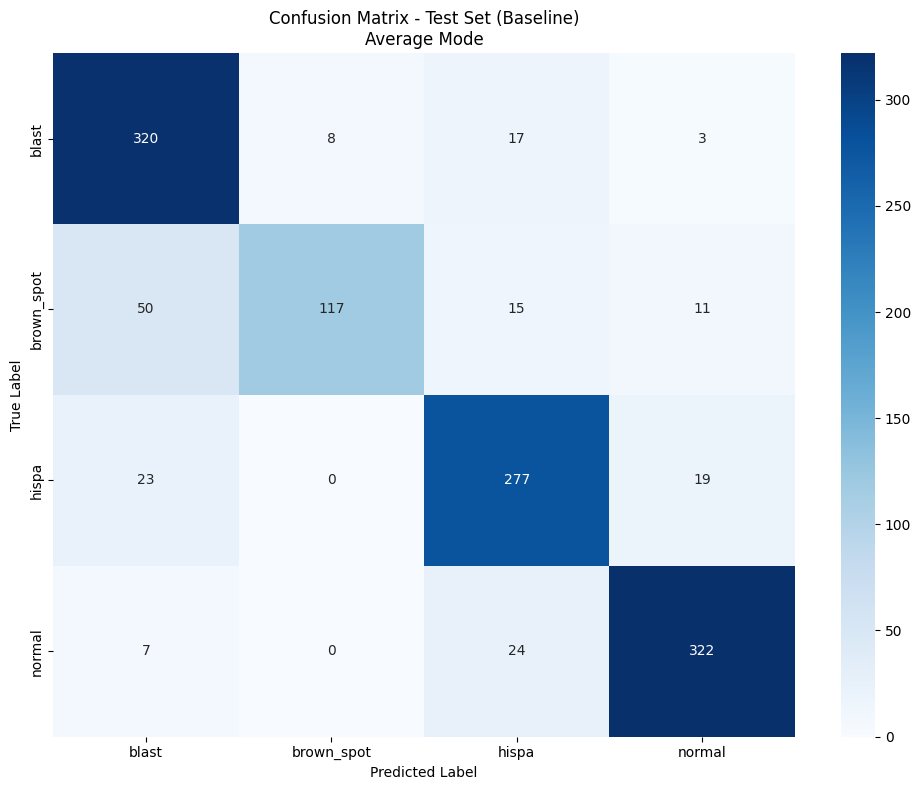

In [ ]:
# Final Evaluation pada Test Set (Unseen Data)
print(f"\n{'='*60}")
print("FINAL EVALUATION ON UNSEEN TEST SET")
print(f"Using: {'AVG (Average of all {K_FOLDS} folds)' if USE_AVG else f'BEST FOLD (Fold {np.argmax(fold_accuracies) + 1})'}")
print(f"{'='*60}\n")

y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

if USE_AVG:
    # AVG: Rata-rata prediksi dari semua fold
    print("Generating predictions from all folds (Averaging)...")
    all_predictions = []

    for i, model in enumerate(fold_models):
        pred = model.predict(X_test, verbose=0)
        all_predictions.append(pred)
        print(f"  Fold {i+1} predictions generated")

    # Average predictions (Model Averaging)
    y_pred_probs = np.mean(all_predictions, axis=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate average loss
    test_loss = tf.keras.losses.categorical_crossentropy(y_test_cat, y_pred_probs).numpy().mean()
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\nAverage Model Test Loss: {test_loss:.4f}")
    print(f"Average Model Test Accuracy: {test_acc:.4f}\n")

else:
    # BEST FOLD: Gunakan model terbaik saja
    best_fold_idx = np.argmax(fold_accuracies)
    best_model = fold_models[best_fold_idx]
    print(f"Using model from Fold {best_fold_idx + 1}")

    test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
    y_pred_probs = best_model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nBest Fold Test Loss: {test_loss:.4f}")
    print(f"Best Fold Test Accuracy: {test_acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title(f'Confusion Matrix - Test Set (Baseline)\n{"Average Mode" if USE_AVG else "Best Fold"}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_matrix.png', dpi=300)
plt.show()

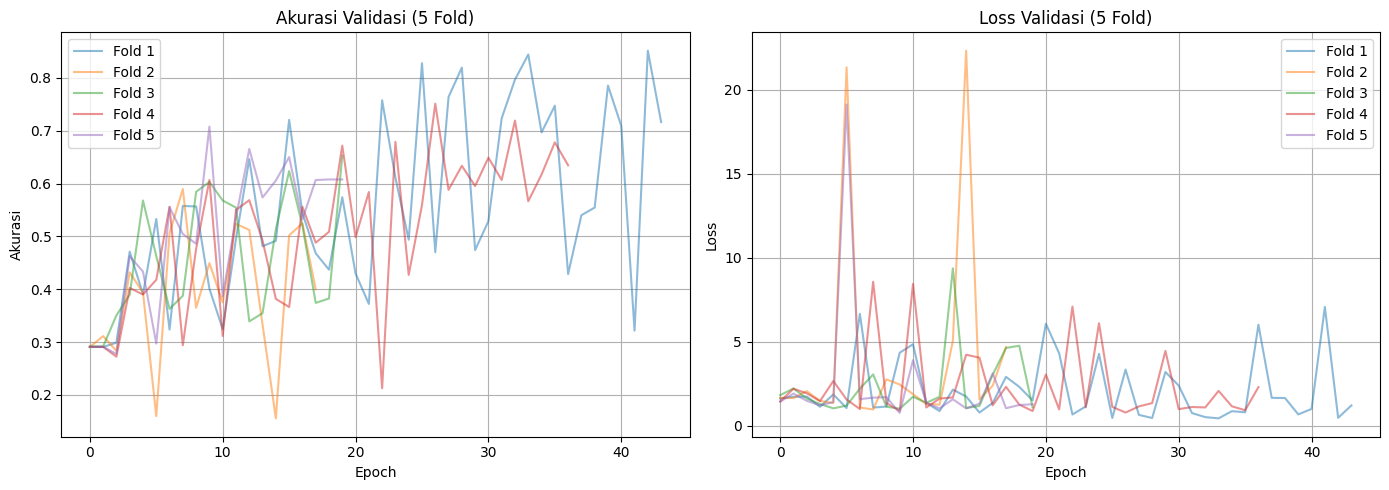

In [ ]:
# plot hasil 5 fold
plt.figure(figsize=(14, 5))

# --- PLOT AKURASI (KIRI) ---
plt.subplot(1, 2, 1)
for i, h in enumerate(fold_histories):
    # Plot tiap fold dengan warna abu-abu
    plt.plot(h['val_accuracy'], label=f'Fold {i+1}', alpha=0.5)

plt.title('Akurasi Validasi (5 Fold)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# --- PLOT LOSS (KANAN) ---
plt.subplot(1, 2, 2)
for i, h in enumerate(fold_histories):
    # Plot tiap fold dengan warna abu-abu
    plt.plot(h['val_loss'], label=f'Fold {i+1}', alpha=0.5)

plt.title('Loss Validasi (5 Fold)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/training_history_baseline.png', dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):
    # ambil semua index yang termasuk kelas ini
    indices = np.where(y_test == i)[0]
    # pilih 5 secara acak
    selected_indices = np.random.choice(indices, 5, replace=False)

    for j, idx in enumerate(selected_indices):
        plt.subplot(NUM_CLASSES, 5, i * 5 + j + 1)
        plt.imshow(X_test[idx])

        # prediksi vs Asli
        p_idx = y_pred[idx]
        is_correct = (i == p_idx)

        title = f"Actual: {class_name}\nPred: {class_names[p_idx]}"
        plt.title(title, color='green' if is_correct else 'red', fontsize=9)
        plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Save Models & Results

# Save semua model fold (format .keras)
for i, model in enumerate(fold_models):
    model_path = f'/content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold{i+1}_final.keras'
    model.save(model_path)
    print(f"Fold {i+1} model saved: {model_path}")

# Save hasil k-fold
results = {
    'fold_scores': fold_scores,
    'fold_histories': fold_histories,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'class_names': class_names,
    'confusion_matrix': cm,
    'use_avg': USE_AVG,
    'num_folds': K_FOLDS,
    'mean_val_accuracy': np.mean(fold_accuracies),
    'std_val_accuracy': np.std(fold_accuracies),
    'predictions': y_pred,
    'prediction_probs': y_pred_probs,
    'model_type': 'baseline'
}

with open('/content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/kfold_results_skenario 1A.pkl', 'wb') as f:
    pickle.dump(results, f)

print(f"\nResults saved to: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/kfold_results_skenario 1A.pkl")


print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/")
print(f"Format: .keras")
if USE_AVG:
    print(f"Mode: AVG ({K_FOLDS} models)")
else:
    print(f"Mode: BEST FOLD (Fold {np.argmax(fold_accuracies) + 1})")

Fold 1 model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold1_final.keras
Fold 2 model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold2_final.keras
Fold 3 model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold3_final.keras
Fold 4 model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold4_final.keras
Fold 5 model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/skenario1A_fold5_final.keras

Results saved to: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/kfold_results_skenario 1A.pkl

Final Test Accuracy: 0.8541
Model saved: /content/drive/MyDrive/22-023_Ali Ridho/models/Skenario 1 A/
Format: .keras
Mode: AVG (5 models)
